Importing Libraries

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms
from torchvision import datasets

from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [4]:
transform = transforms.Compose([
    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std = [0.229, 0.224, 0.225]
    )
])

Loading Dataset

In [5]:
train_dataset = datasets.Flowers102(
    root  = './data',
    split = 'train',
    download = True,
    transform = transform
)

val_dataset = datasets.Flowers102(
    root  = './data',
    split = 'val',
    download = True,
    transform = transform
)

test_dataset = datasets.Flowers102(
    root  = './data',
    split = 'test',
    download = True,
    transform = transform
)

In [6]:
print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

1020
1020
6149


In [7]:
train_loader = DataLoader(
    train_dataset,
    batch_size = 32,
    shuffle = True
)

val_loader = DataLoader(
    val_dataset,
    batch_size = 32,
    shuffle = False
)

test_loader = DataLoader(
    test_dataset,
    batch_size = 32,
    shuffle = False
)

In [8]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


Feature Extraction

In [9]:
from torchvision.models import vit_b_16, ViT_B_16_Weights

In [10]:
weights = ViT_B_16_Weights.DEFAULT
model = vit_b_16(weights= weights)

In [11]:
print(model)

VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_a

Freezing Backbone Layers

In [12]:
for param in model.parameters():
    param.requires_grad = False

In [13]:
num_features = model.heads.head.in_features
model.heads.head = nn.Linear(num_features, 102)

In [14]:
model = model.to(device)

In [15]:
print(model.heads.head)

Linear(in_features=768, out_features=102, bias=True)


In [16]:
criterion = nn.CrossEntropyLoss()

In [17]:
optimizer = torch.optim.Adam(
    model.heads.head.parameters(),
    lr = 0.001
)

epochs = 10

In [18]:
train_losses = []
val_losses =[]

train_accuracies = []
val_accuracies = []

for epoch in range(epochs):
    model.train()

    running_loss = 0
    correct = 0
    total =0

    for images,labels in train_loader:
        images = images.to(device)
        labels= labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted==labels).sum().item()
    
    train_loss = running_loss / len(train_loader)
    train_accuracy = 100* correct/total

    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)


    model.eval()

    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images.labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted==labels).sum().item()

    val_loss = val_loss / len(val_loader)
    val_accuracy = 100 * correct/total

    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    print(f"Epoch [{epoch+1}/{epochs}] | "
          f"Train Accuracy: {train_accuracy:.2f} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Accuracy: {val_accuracy:.2f} | "
          f"Val Loss: {val_loss:.4f}"
    )

Epoch [1/10] | Train Accuracy: 17.16 | Train Loss: 4.1079 | Val Accuracy: 39.29 | Val Loss: 3.2743
Epoch [2/10] | Train Accuracy: 71.76 | Train Loss: 2.4034 | Val Accuracy: 78.57 | Val Loss: 1.9208
Epoch [3/10] | Train Accuracy: 88.53 | Train Loss: 1.4636 | Val Accuracy: 100.00 | Val Loss: 1.1641
Epoch [4/10] | Train Accuracy: 93.63 | Train Loss: 0.9547 | Val Accuracy: 96.43 | Val Loss: 0.8195
Epoch [5/10] | Train Accuracy: 96.57 | Train Loss: 0.6684 | Val Accuracy: 96.43 | Val Loss: 0.7955
Epoch [6/10] | Train Accuracy: 98.14 | Train Loss: 0.4896 | Val Accuracy: 100.00 | Val Loss: 0.4489
Epoch [7/10] | Train Accuracy: 98.43 | Train Loss: 0.3761 | Val Accuracy: 100.00 | Val Loss: 0.3402
Epoch [8/10] | Train Accuracy: 99.51 | Train Loss: 0.2951 | Val Accuracy: 100.00 | Val Loss: 0.2404
Epoch [9/10] | Train Accuracy: 99.80 | Train Loss: 0.2385 | Val Accuracy: 100.00 | Val Loss: 0.2253
Epoch [10/10] | Train Accuracy: 99.90 | Train Loss: 0.1941 | Val Accuracy: 100.00 | Val Loss: 0.1675


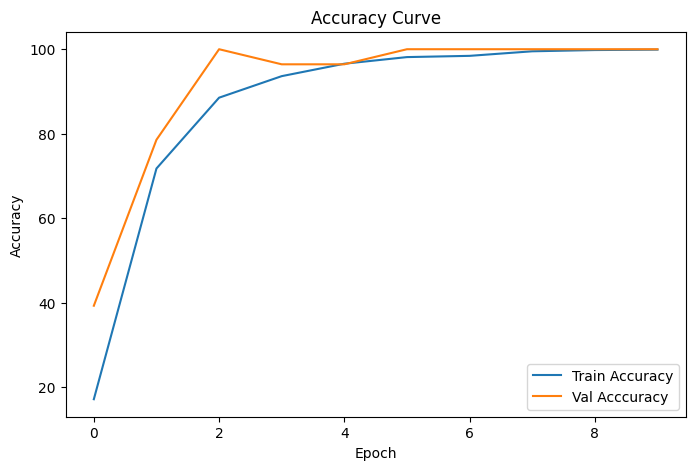

In [19]:
plt.figure(figsize=(8,5))

plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Val Acccuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")

plt.legend()
plt.show()

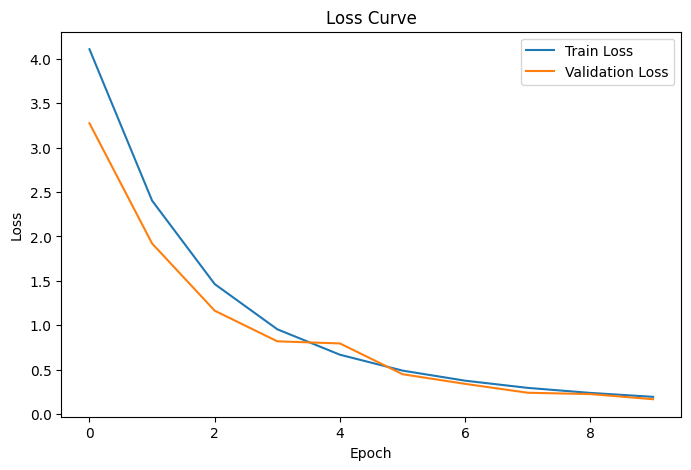

In [20]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")

plt.legend()
plt.show()

In [21]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs,1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy3 = 100 * correct / total

print("Test Accuracy:", test_accuracy3)

Test Accuracy: 82.69637339404781


In [23]:
cm= confusion_matrix(all_labels, all_preds)

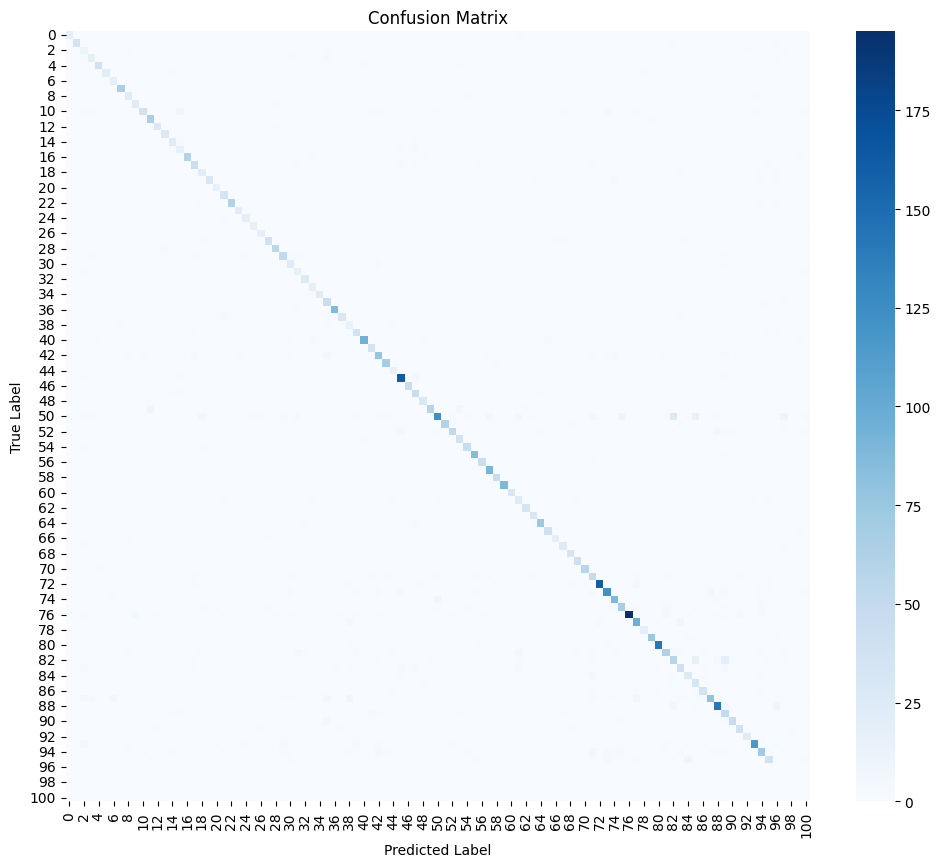

In [24]:
plt.figure(figsize=(12,10))

sns.heatmap(cm, cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [25]:
from sklearn.metrics import classification_report

print(classification_report(all_labels, all_preds, digits=4))

              precision    recall  f1-score   support

           0     0.7308    0.9500    0.8261        20
           1     0.9730    0.9000    0.9351        40
           2     0.2778    0.5000    0.3571        20
           3     0.6250    0.5556    0.5882        36
           4     0.8889    0.8889    0.8889        45
           5     1.0000    0.8800    0.9362        25
           6     0.6786    0.9500    0.7917        20
           7     0.9848    1.0000    0.9924        65
           8     0.7419    0.8846    0.8070        26
           9     0.8276    0.9600    0.8889        25
          10     0.7917    0.5672    0.6609        67
          11     0.8904    0.9701    0.9286        67
          12     0.9333    0.9655    0.9492        29
          13     0.9032    1.0000    0.9492        28
          14     0.6053    0.7931    0.6866        29
          15     0.5161    0.7619    0.6154        21
          16     0.9836    0.9231    0.9524        65
          17     0.6935    

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Fine Tuning

In [26]:
from torchvision.models import vit_b_16, ViT_B_16_Weights

weights = ViT_B_16_Weights.DEFAULT
model2 = vit_b_16(weights = weights)

In [27]:
for param in model2.parameters():
    param.requires_grad = False

In [28]:
num_features = model2.heads.head.in_features
model2.heads.head = nn.Linear(num_features, 102)

In [29]:
print(model2)

VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_a

Unfreezing Transformer Encoder

In [30]:
for param in model2.encoder.parameters():
    param.requires_grad= True

In [31]:
model2 = model2.to(device)

In [32]:
criterion2 = nn.CrossEntropyLoss()

In [33]:
optimizer2 = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model2.parameters()),
    lr = 0.0001
)

epochs2 = 5

In [34]:
train_losses2 = []
val_losses2 = []

train_accuracies2 = []
val_accuracies2 = []

for epoch in range(epochs2):

    model2.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer2.zero_grad()

        outputs = model2(images)

        loss = criterion2(outputs, labels)

        loss.backward()

        optimizer2.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()


    train_loss = running_loss / len(train_loader)
    train_accuracy = 100 * correct / total

    train_losses2.append(train_loss)
    train_accuracies2.append(train_accuracy)



    model2.eval()

    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model2(images)

            loss = criterion2(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()


    val_loss = val_loss / len(val_loader)
    val_accuracy = 100 * correct / total

    val_losses2.append(val_loss)
    val_accuracies2.append(val_accuracy)


    print(f"Epoch [{epoch+1}/{epochs2}] | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Train Acc: {train_accuracy:.2f}% | "
          f"Val Acc: {val_accuracy:.2f}%")

Epoch [1/5] | Train Loss: 3.9831 | Val Loss: 2.6403 | Train Acc: 20.00% | Val Acc: 63.14%
Epoch [2/5] | Train Loss: 1.4643 | Val Loss: 1.3031 | Train Acc: 90.20% | Val Acc: 88.92%
Epoch [3/5] | Train Loss: 0.3581 | Val Loss: 0.7632 | Train Acc: 99.90% | Val Acc: 93.14%
Epoch [4/5] | Train Loss: 0.0901 | Val Loss: 0.5955 | Train Acc: 100.00% | Val Acc: 93.82%
Epoch [5/5] | Train Loss: 0.0435 | Val Loss: 0.5500 | Train Acc: 100.00% | Val Acc: 93.82%


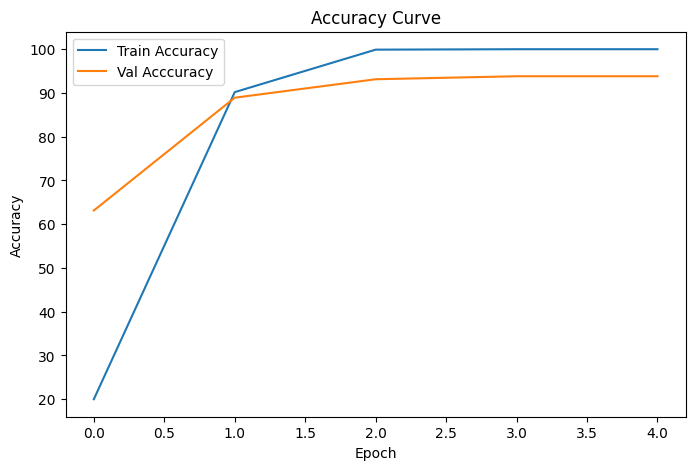

In [35]:
plt.figure(figsize=(8,5))

plt.plot(train_accuracies2, label="Train Accuracy")
plt.plot(val_accuracies2, label="Val Acccuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")

plt.legend()
plt.show()

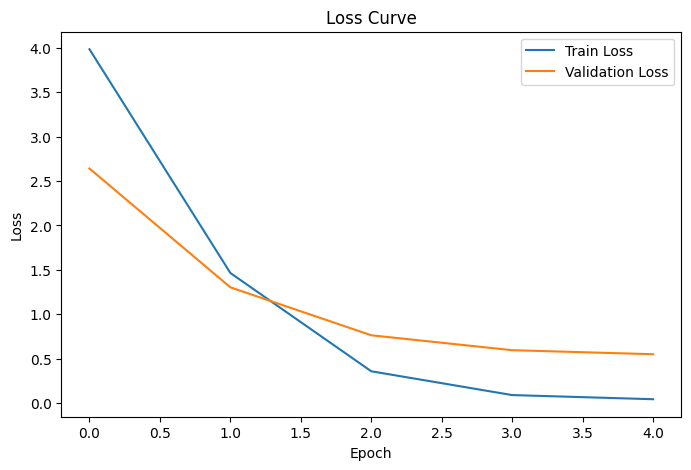

In [36]:
plt.figure(figsize=(8,5))

plt.plot(train_losses2, label="Train Loss")
plt.plot(val_losses2, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")

plt.legend()
plt.show()

In [37]:
model2.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model2(images)

        _, predicted = torch.max(outputs,1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = 100 * correct / total

print("Test Accuracy:", test_accuracy)

Test Accuracy: 93.21840949747927


In [38]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

all_preds= []
all_labels= []

model2.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model2(images)

        _, predicted = torch.max(outputs,1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

In [39]:
cm= confusion_matrix(all_labels, all_preds)

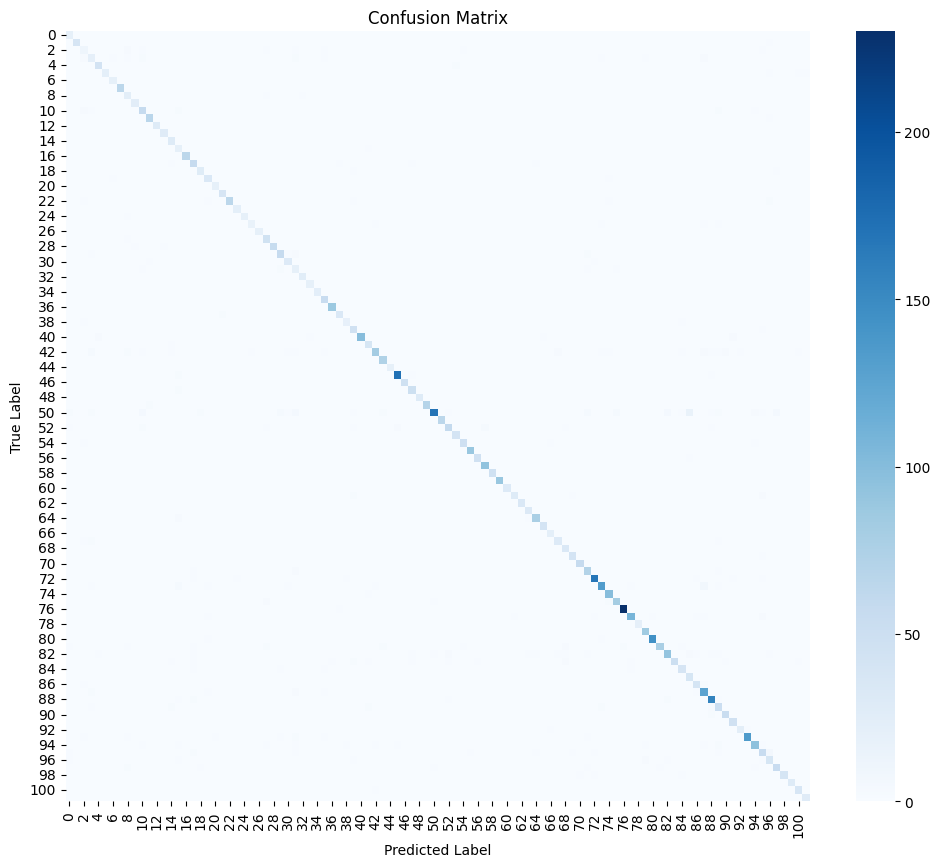

In [40]:
plt.figure(figsize=(12,10))

sns.heatmap(cm, cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [41]:
from sklearn.metrics import classification_report

print(classification_report(all_labels, all_preds, digits=4))

              precision    recall  f1-score   support

           0     0.7692    1.0000    0.8696        20
           1     1.0000    0.9750    0.9873        40
           2     0.4783    0.5500    0.5116        20
           3     0.6000    0.5833    0.5915        36
           4     0.9149    0.9556    0.9348        45
           5     1.0000    0.8800    0.9362        25
           6     0.9091    1.0000    0.9524        20
           7     1.0000    1.0000    1.0000        65
           8     0.6667    0.9231    0.7742        26
           9     0.9615    1.0000    0.9804        25
          10     0.8169    0.8657    0.8406        67
          11     0.9565    0.9851    0.9706        67
          12     1.0000    1.0000    1.0000        29
          13     0.9655    1.0000    0.9825        28
          14     0.8286    1.0000    0.9062        29
          15     0.5556    0.9524    0.7018        21
          16     1.0000    1.0000    1.0000        65
          17     0.8529    